In [32]:
from astropy.io import fits
from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from matplotlib.colors import LogNorm

In [33]:
#Import and inspect the data from the fits
hudl  = fits.open(r'data\nihao_uhd_simulation_g8.26e11_xyz_positions_and_oxygen_ao.fits')
print(hudl)
#covert to a astropy table for easier manipulation
data = Table(hudl[1].data)
print(data.columns)

[<astropy.io.fits.hdu.image.PrimaryHDU object at 0x00000155E6C0B9D0>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x00000155E1AD3B10>]
<TableColumns names=('x','y','z','A_O')>


In [34]:
#compute the galactic radius for each star and add it to the table
data.add_column(np.sqrt(data['x']**2+data['y']**2),name = 'R_Gal')

In [35]:
#define a linear function
def lin(x,m,c):
    return m*x+c

In [36]:
#fit the linear model for metalicity as a function of galactic radius
params, pcov = curve_fit(lin,data['R_Gal'],data['A_O'],p0=[-0.5/15,9.1])
#compute the model value and residual for each star
data.add_column(lin(data['R_Gal'],*params),name = 'model')
data.add_column(data['A_O']-data['model'], name = 'residual')

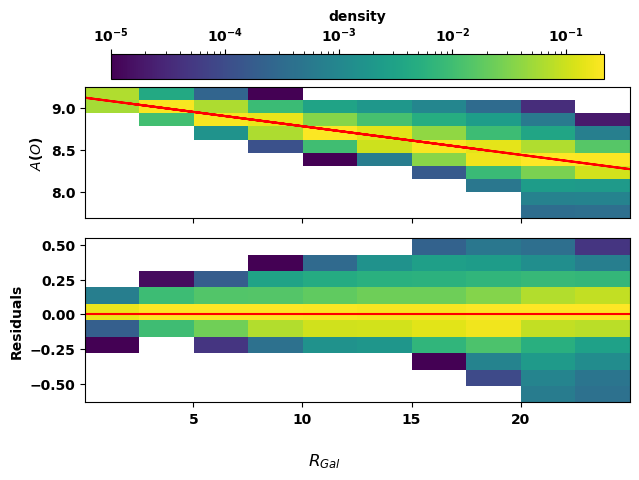

In [37]:
#create a 2 panel plot
fig, axs = plt.subplots(2,sharex=True)
#use a 2d histogram to plot the gas phase metalicity against the galactic radius with a colorbar
h, x_edge, y_edge, im = axs[0].hist2d(data['R_Gal'],data['A_O'],density = True,norm = LogNorm())
cbar = plt.colorbar(im,ax=axs[0],location = 'top',label='density')
#add the model plot
axs[0].plot(data['R_Gal'],data['model'],c='r')
#plot the residuals, and the model in residual space
axs[1].hist2d(data['R_Gal'],data['residual'],density = True, norm = LogNorm(np.min(h[h>0]),np.max(h)))
axs[1].axhline(y=0,c='r')
axs[1].set_facecolor('white')
#label the axes
axs[0].set_ylabel('$A(O)$')
axs[1].set_ylabel('Residuals')
fig.supxlabel('$R_{Gal}$')
#save the figure
fig.tight_layout()
fig.savefig(r'figures\A_vs_Grad.png')

In [38]:
#get the slope and intercept of the model
print(f'the slope is m={params[0]:.5f}+-{np.sqrt(pcov[0,0]):.02}')
print(f'the intercept is c={params[1]:.4f}+-{np.sqrt(pcov[1,1]):.02}')

the slope is m=-0.03420+-1.5e-05
the intercept is c=9.1278+-0.00023


![](figures\A_vs_Grad.png)

using ```scipy.optimize.curvefit``` the slope and intercept of the linear model in the above plot are $m=-0.03420\pm1.5\times10^{-10},\;c=9.1278\pm0.00023$. these parameters were computed using a Levenberg-Marquardt algorithm for least squares fitting with no bounds and innitial conditions of $m_0=-\frac{1}{30},\;c_0=9.1$ which were estimated from reading the plot.

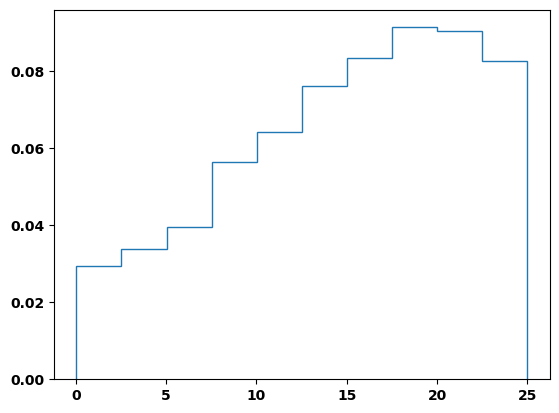

In [51]:
#compute root mean square and plot
bin_edges = np.linspace(min(data['R_Gal']),max(data['R_Gal']),11)
RMSEs = []
for i in range(len(bin_edges)-1):
    RMSE = np.sqrt(np.mean(data['residual'][(data['R_Gal']<bin_edges[i+1]) & (data['R_Gal']>bin_edges[i])]**2))
    RMSEs.append(RMSE)
plt.stairs(RMSEs,bin_edges)

The linear fit fits the data well across the entire range of values, with a root mean squared error of \lt 0.1 across the entire space. the fit is better at lower values of $R_{gal}$ with $RMSE\lt0.04$ for $R_{gal}\lt7.5$. the RMSE increases slightly faster than linearly with galactic radius but this is due to increased scatter in the Gas Phase Metallicity as can be seen from the 2 panel plot, not inaccuracy of the model, at least over the region of the simulation provided.

(array([[    0.,     0.,   873.,  1339.,  3280.,  3310.,  1701.,  1011.,
             0.,     0.],
        [    0.,  1742.,  2791.,  4965.,  6270.,  9550.,  8054.,  4503.,
          1863.,     0.],
        [ 2976.,  4177.,  1656.,  4949.,  8811.,  7248.,  4855.,  1261.,
          2649.,   845.],
        [ 3746.,  2838.,  2834.,  6940., 10478.,  8979., 13771.,  5579.,
          5733.,  5244.],
        [ 8018.,  6036.,  4470., 13154., 18439., 20127.,  8099.,  6621.,
          5234.,  5750.],
        [ 5420.,  5606., 10147., 10003., 18513., 17540.,  8474.,  5348.,
          5843.,  3931.],
        [ 3607.,  4276.,  2806.,  6757.,  8183.,  8265.,  5671.,  7471.,
          7438.,  5441.],
        [ 1302.,  6043.,  7585.,  4321.,  3995.,  6229.,  8219.,  6500.,
          7279.,  1295.],
        [    0.,  2549.,  4431.,  6803.,  4528.,  6550.,  5104.,  6176.,
          3522.,     0.],
        [    0.,     0.,   597.,  1180.,  3402.,  5401.,  3909.,  1091.,
             0.,     0.]]),
 array([

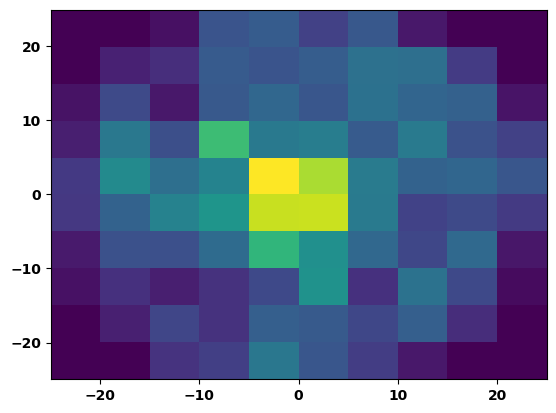

In [39]:
#look at stellar densities to choose bins
plt.hist2d(data['x'],data['y'])

In [40]:
#find the percitle such that there are an integer number of bins and approximetaly 500 stars in each bin
percentile_options = [5**i*2**j for i in range(3) for j in range(3)]
num_stars = len(data)
pct = np.sqrt(500/num_stars)
pct = min(percentile_options, key=lambda x: abs(x-100*pct))
num_bins = int(100/pct)
#define the edges and centers of the bins
x_bin_edges = [np.percentile(data['x'],pct*i) for i in range(num_bins)]
x_bin_edges.append(data['x'][-1])
y_bin_edges = [np.percentile(data['y'],pct*i) for i in range(num_bins)]
y_bin_edges.append(data['y'][-1])
x_bin_centers = [(x_bin_edges[i]+x_bin_edges[i+1])/2 for i in range(num_bins)]
y_bin_centers = [(y_bin_edges[i]+y_bin_edges[i+1])/2 for i in range(num_bins)]

In [41]:
#initialize binning columns in the table
data.add_column(np.ones_like(data['x']),name = 'x_bin')
data.add_column(np.ones_like(data['y']),name = 'y_bin')

In [42]:
#set the x and y bins for each star
for i,row in enumerate(data):
    for j in range(num_bins):
        if row['x']<=x_bin_edges[j+1] and row['x']>x_bin_edges[j]:
            row['x_bin'] = j
        if row['y']<=y_bin_edges[j+1] and row['y']>y_bin_edges[j]:
            row['y_bin'] = j

In [43]:
#fix the wrong bin for lowest valued stars in x and y
data['x_bin'][np.argmin(data['x'])] = 0.0
data['y_bin'][np.argmin(data['y'])] = 0.0

In [44]:
#use astropy's built in binning functionality to get a table of values for bins
grouped_data = data.group_by(['x_bin','y_bin'])
binned_data = grouped_data.groups.aggregate(np.median)

In [45]:
#make bin labels integers so they can be used to index
binned_data['x_bin'] = binned_data['x_bin'].astype(int)
binned_data['y_bin'] = binned_data['y_bin'].astype(int)
#put the bin centers in the table
binned_data['x'] = [x_bin_centers[i] for i in binned_data['x_bin']]
binned_data['y'] = [y_bin_centers[i] for i in binned_data['y_bin']]

In [46]:
#put the binned data on a grid for plotting
grid = np.full((num_bins,num_bins),np.nan)
AO_sim_grid = grid.copy()
AO_sim_grid[binned_data['y_bin'],binned_data['x_bin']] = binned_data['A_O']
AO_mod_grid = grid.copy()
AO_res_grid = grid.copy()
AO_mod_grid[binned_data['y_bin'],binned_data['x_bin']] = binned_data['model']
AO_res_grid[binned_data['y_bin'],binned_data['x_bin']] = binned_data['residual']

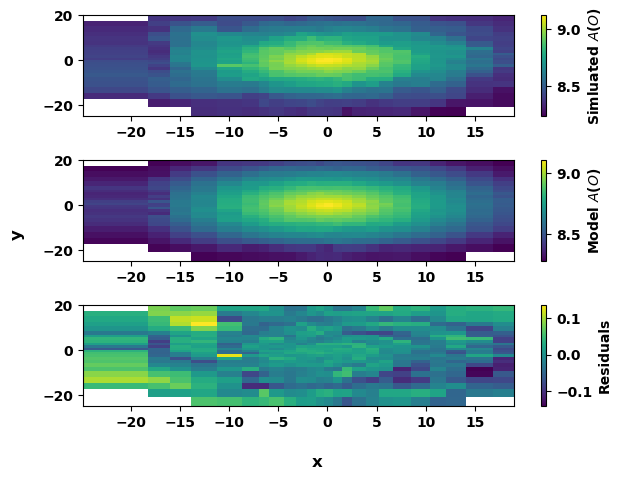

In [47]:
#plot the grids
fig, axs = plt.subplots(3)
sim_img = axs[0].pcolormesh(x_bin_edges,y_bin_edges,AO_sim_grid)
plt.colorbar(sim_img,ax=axs[0],label=r'Simluated $A(O)$')
mod_img = axs[1].pcolormesh(x_bin_edges,y_bin_edges,AO_mod_grid)
plt.colorbar(mod_img,ax=axs[1],label=r'Model $A(O)$')
res_img = axs[2].pcolormesh(x_bin_edges,y_bin_edges,AO_res_grid)
plt.colorbar(res_img,ax=axs[2],label=r'Residuals')
fig.supxlabel('x')
fig.supylabel('y')
fig.tight_layout()
fig.savefig('figures/binned_AO')

the bins were chosen such that each bin has approximetaly 500 stars in it. fewer bins will result in a loss of detail, particlularly the slight asymetries in the galaxy. using more bins will result in fewer stars per bin, and thus a loss of statistical significance. more bins were used near the center of the galaxy than the edges as there are near the edges, so a smaller bin can achive the same statistical significance.

there are large curving spaces where the gas is under dense compared to the model visible in the residuals. additionally, the $-x$ side of is relatively over-dense while the positive $x$ side is under dense. the curving regions are likely galactic arms with star forming regions pulling metals out of the gas. the asymmetry in the metallicity is likely due to inhomogeneous mixing of the metals or recent enrichment due to stellar activity.